# `annotation_raster()`

`annotation_raster()` adds a raster image as a regular plot layer. It does not use aesthetics, but it participates in the layer order: layers added later are drawn on top of earlier layers.

The image is passed as encoded image bytes. Missing bounds (`None`) mean that the corresponding image edge is aligned with the plot panel edge.


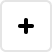
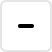
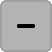
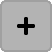
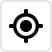
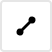
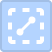
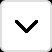
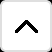
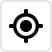
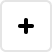
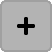
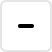
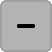
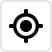
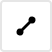
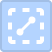
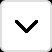
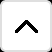
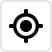

In [1]:
import numpy as np
import pandas as pd
import requests
from lets_plot import *

LetsPlot.setup_html()

In [2]:
with open("./images/blackRedCross.png", "rb") as f:
    image_bytes = f.read()

## Default Bounds

When no bounds are specified, the raster fills the whole plot panel. In this example the raster layer is added before the point layer, so the points are drawn on top of the image.


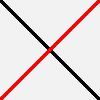

In [3]:
ggplot({"x": [1, 2], "y": [2, 1]}, aes("x", "y")) + \
    annotation_raster(image_bytes) + \
    geom_point(size=8)    

## Partially Specified Bounds

Each bound can be controlled independently. Here `xmin` and `ymin` are fixed in data coordinates, while `xmax=None` and `ymax=None` extend the image to the corresponding panel edges.

The raster layer is added after the points, so it is drawn above them.


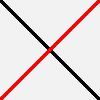

In [4]:
ggplot({"x": [1, 2], "y": [2, 1]}, aes("x", "y")) + \
    geom_point(size=8) + \
    annotation_raster(
        image_bytes,
        xmin=1.2,
        xmax=None,
        ymin=1.2,
        ymax=None,
        interpolate=True
    )

## Bounds Outside the Plot Range

Bounds can be outside the visible coordinate range. The image is positioned according to those data coordinates and only the visible part appears inside the panel.


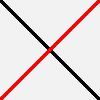

In [5]:
ggplot({"x": [1, 2], "y": [2, 1]}, aes("x", "y")) + \
    geom_point(size=8) + \
    annotation_raster(
        image_bytes,
        xmin=0,
        xmax=3,
        ymin=0,
        ymax=3
    )

## Pixel Interpolation

The `interpolate` parameter controls how the image is scaled. With `interpolate=False`, pixels are kept sharp. With `interpolate=True`, the renderer can smooth the image while resizing it.


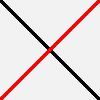
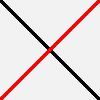

In [6]:
data = {"x": [1, 2], "y": [2, 1]}

p1 = ggplot(data, aes("x", "y")) + \
    annotation_raster(image_bytes, interpolate=False) + \
    geom_point(size=8, color="red")


p2 = ggplot(data, aes("x", "y")) + \
    annotation_raster(image_bytes, interpolate=True) + \
    geom_point(size=8, color="red")

gggrid([p1 + ggtitle("interpolate=False"),
        p2 + ggtitle("interpolate=True")])